In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('../E-commerce_data/Cleaned.csv')

In [3]:
pd.set_option('display.max_columns',None)

In [4]:
df.head(3)

,Unnamed: 0.1,Unnamed: 0,OrderId,CustomerId,OrderDate,Age,City,Category,ProductName,Quantity,UnitPrice,DiscountPct,PaymentMethod,OrderStatus,Rating,ShippingDays,DeliveryDistanceKM,Device,MarketingChannel,Spend90d,CouponCode,TotalAmount,Year,Month,Day
0,0,0,ORD1048298,CUST55152,NaN,33,Lucknow,Grocery,Bluetooth Speaker,1.0,1270.11,15.27,COD,Delivered,3.6,4.0,4.74,Desktop,Social,10552.73,NEWUSER,1076.16,NaN,NaN,NaN
1,1,1,ORD1081047,CUST35058,2025-08-14,28,Chennai,Home & Kitchen,Running Shoes,1.0,1030.57,1.50,UPI,Delivered,5.0,3.0,16.72,Mobile,Social,894.36,FESTIVE,1015.11,2025.0,8.0,14.0
2,2,2,ORD1092754,CUST67495,2025-11-08,31,Pune,Beauty,Face Serum,1.0,284.83,15.65,UPI,Delivered,5.0,6.0,4.40,Mobile,Organic,9866.55,NEWUSER,240.25,2025.0,11.0,8.0


### Which Category genrate highest Revenue

In [5]:
category_df = df.groupby('Category')['TotalAmount'].median().reset_index()

### Observation:
Most categories generate similar revenue, with no strong revenue difference among them. However, the not provided category has comparatively higher revenue and should be investigated because it represents missing category information.

C:\Users\md salman\AppData\Local\Temp\ipykernel_20172\2366804138.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(category_df, x="Category", y="TotalAmount", palette='Set2')


<Axes: xlabel='Category', ylabel='TotalAmount'>

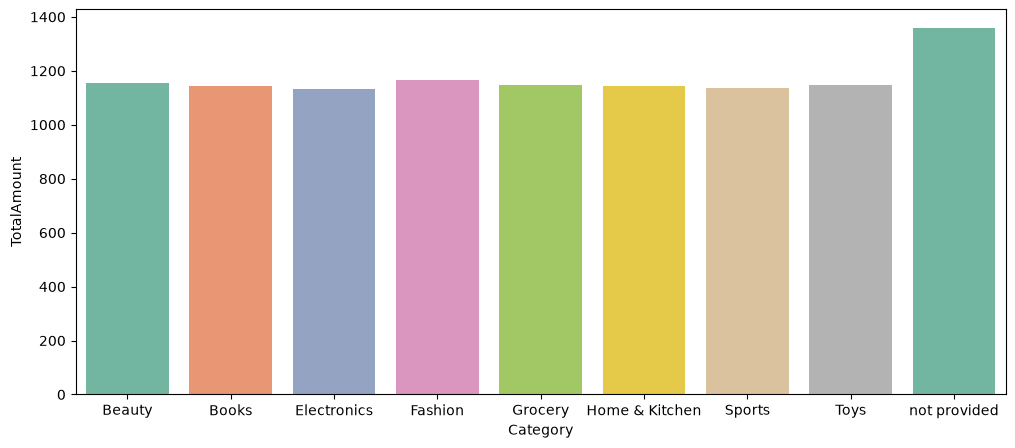

In [6]:
plt.figure(figsize=(12,5))
sns.barplot(category_df, x="Category", y="TotalAmount", palette='Set2')

### Which Product Genrate High Revenue

In [7]:
df.head(3)

,Unnamed: 0.1,Unnamed: 0,OrderId,CustomerId,OrderDate,Age,City,Category,ProductName,Quantity,UnitPrice,DiscountPct,PaymentMethod,OrderStatus,Rating,ShippingDays,DeliveryDistanceKM,Device,MarketingChannel,Spend90d,CouponCode,TotalAmount,Year,Month,Day
0,0,0,ORD1048298,CUST55152,NaN,33,Lucknow,Grocery,Bluetooth Speaker,1.0,1270.11,15.27,COD,Delivered,3.6,4.0,4.74,Desktop,Social,10552.73,NEWUSER,1076.16,NaN,NaN,NaN
1,1,1,ORD1081047,CUST35058,2025-08-14,28,Chennai,Home & Kitchen,Running Shoes,1.0,1030.57,1.50,UPI,Delivered,5.0,3.0,16.72,Mobile,Social,894.36,FESTIVE,1015.11,2025.0,8.0,14.0
2,2,2,ORD1092754,CUST67495,2025-11-08,31,Pune,Beauty,Face Serum,1.0,284.83,15.65,UPI,Delivered,5.0,6.0,4.40,Mobile,Organic,9866.55,NEWUSER,240.25,2025.0,11.0,8.0




### Category-wise Total Revenue & Orders

In [8]:
category_insight = (
    df.groupby("Category")
      .agg(
          Total_Revenue=("TotalAmount", "sum"),
          Total_Orders=("OrderId", "nunique"),
          Total_Quantity=("Quantity", "sum"),
          Avg_Order_Value=("TotalAmount", "mean")
      )
      .sort_values("Total_Revenue", ascending=False)
)

category_insight

,Total_Revenue,Total_Orders,Total_Quantity,Avg_Order_Value
Category,,,,
Home & Kitchen,1.757782e+08,11209,34801.0,15807.388065
Beauty,1.558634e+08,10641,32533.0,14750.015847
Grocery,1.491369e+08,10688,34597.0,14084.132908
Books,1.324486e+08,10598,30001.0,12612.948593
Sports,1.321006e+08,10711,34154.0,12431.828232
Toys,1.307763e+08,10674,28205.0,12375.919556
Fashion,1.265529e+08,10816,33245.0,11811.921446
Electronics,1.176790e+08,11297,28485.0,10499.551524
not provided,4.715442e+05,232,622.0,2050.192217


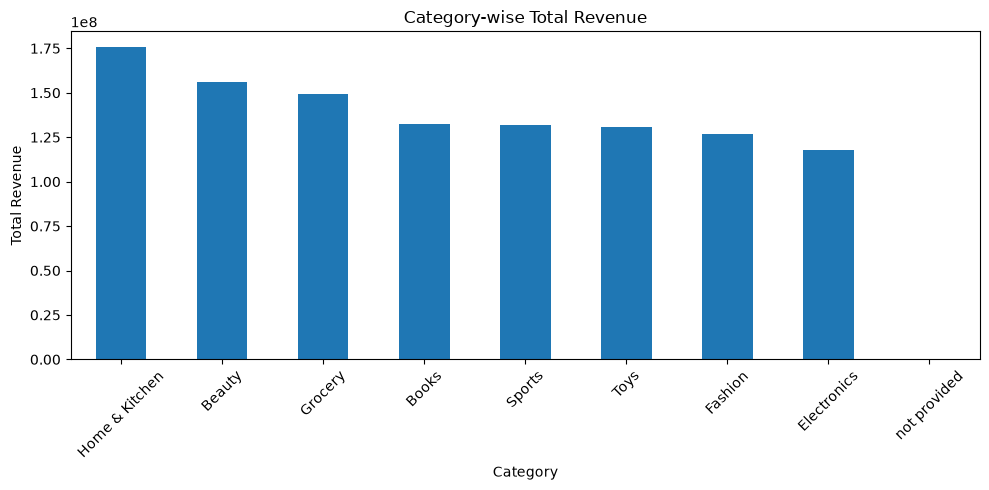

In [ ]:


category_revenue = (
    df.groupby("Category")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
category_revenue.plot(kind="bar")
plt.title("Category-wise Total Revenue")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### High Revenue but Low Quantity Products

In [9]:
product_insight = (
    df.groupby("ProductName")
      .agg(
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("TotalAmount", "sum"),
          Avg_Price=("UnitPrice", "mean")
      )
)

high_revenue_low_quantity = product_insight[
    (product_insight["Total_Revenue"] > product_insight["Total_Revenue"].median()) &
    (product_insight["Total_Quantity"] < product_insight["Total_Quantity"].median())
].sort_values("Total_Revenue", ascending=False)

high_revenue_low_quantity

,Total_Quantity,Total_Revenue,Avg_Price
ProductName,,,
Coffee Maker,24271.0,1.529938e+08,2223.642507
Bluetooth Speaker,21401.0,1.173256e+08,2456.043971
Yoga Mat,23874.0,1.148819e+08,2692.851040


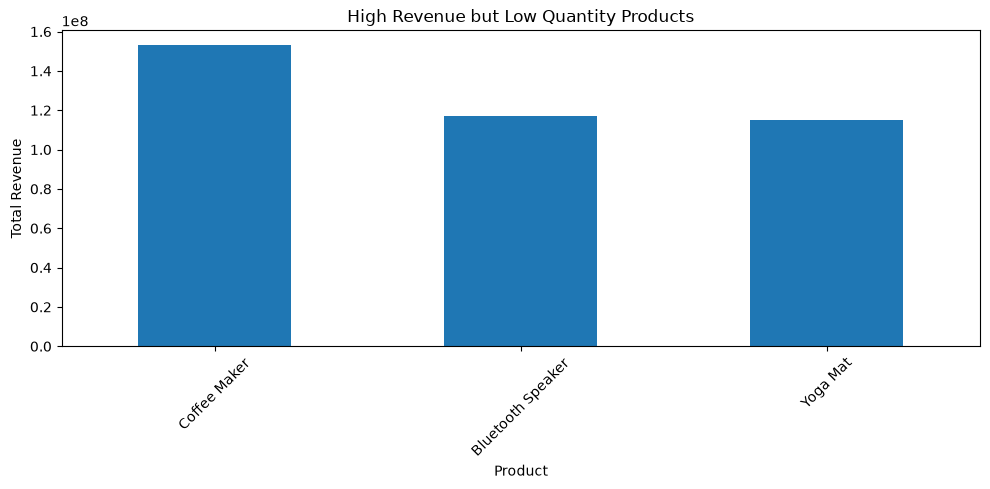

In [21]:
product_insight = (
    df.groupby("ProductName")
      .agg(
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("TotalAmount", "sum")
      )
)

high_revenue_low_quantity = product_insight[
    (product_insight["Total_Revenue"] > product_insight["Total_Revenue"].median()) &
    (product_insight["Total_Quantity"] < product_insight["Total_Quantity"].median())
].sort_values("Total_Revenue", ascending=False).head(10)

plt.figure(figsize=(10, 5))
high_revenue_low_quantity["Total_Revenue"].plot(kind="bar")
plt.title("High Revenue but Low Quantity Products")
plt.xlabel("Product")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Discount ka Revenue par Impact

In [10]:
discount_impact = (
    df.assign(
        Discount_Bucket=pd.cut(
            df["DiscountPct"],
            bins=[-1, 5, 10, 20, 30, 100],
            labels=["0-5%", "5-10%", "10-20%", "20-30%", "30%+"]
        )
    )
    .groupby("Discount_Bucket", observed=True)
    .agg(
        Orders=("OrderId", "nunique"),
        Avg_Revenue=("TotalAmount", "mean"),
        Total_Revenue=("TotalAmount", "sum"),
        Avg_Rating=("Rating", "mean")
    )
)

discount_impact

,Orders,Avg_Revenue,Total_Revenue,Avg_Rating
Discount_Bucket,,,,
0-5%,13050,10265.945197,1.326873e+08,4.027225
5-10%,23220,13916.843115,3.204214e+08,4.025955
10-20%,35556,13527.411841,4.773688e+08,4.029053
20-30%,13209,14344.224951,1.879237e+08,4.039441
30%+,2956,8149.730358,2.393576e+07,4.011367


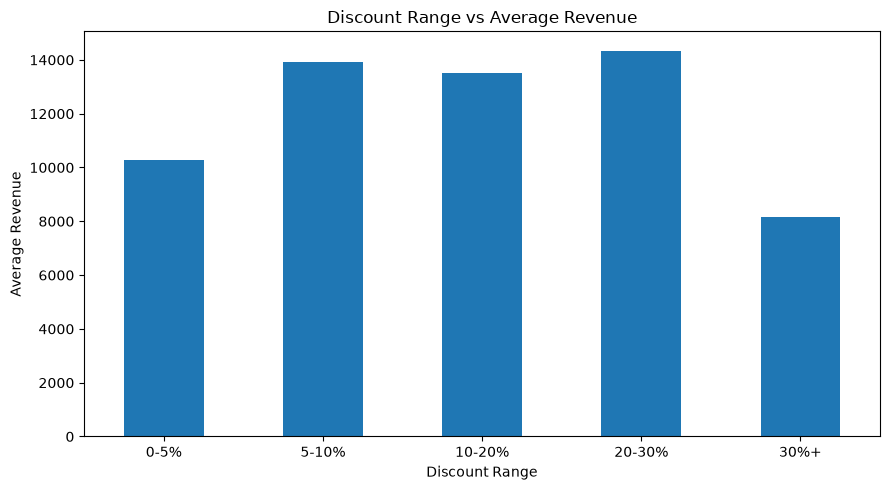

In [22]:
discount_df = df.copy()

discount_df["Discount_Bucket"] = pd.cut(
    discount_df["DiscountPct"],
    bins=[-1, 5, 10, 20, 30, 100],
    labels=["0-5%", "5-10%", "10-20%", "20-30%", "30%+"]
)

discount_revenue = (
    discount_df.groupby("Discount_Bucket", observed=True)["TotalAmount"]
               .mean()
)

plt.figure(figsize=(9, 5))
discount_revenue.plot(kind="bar")
plt.title("Discount Range vs Average Revenue")
plt.xlabel("Discount Range")
plt.ylabel("Average Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Payment Method Performance

In [11]:
payment_insight = (
    df.groupby("PaymentMethod")
      .agg(
          Orders=("OrderId", "nunique"),
          Total_Revenue=("TotalAmount", "sum"),
          Avg_Order_Value=("TotalAmount", "mean"),
          Avg_Rating=("Rating", "mean")
      )
      .sort_values("Total_Revenue", ascending=False)
)

payment_insight

,Orders,Total_Revenue,Avg_Order_Value,Avg_Rating
PaymentMethod,,,,
Net Banking,14463,2.198113e+08,15325.337178,4.025535
UPI,14488,2.006447e+08,13957.889364,4.027399
Wallet,14126,1.976841e+08,14109.208857,4.024513
COD,14779,1.947515e+08,13299.974283,4.023506
Credit Card,14788,1.647592e+08,11228.733055,4.039745
Debit Card,14173,1.544742e+08,10993.037368,4.031105
not provided,1393,1.068312e+07,7763.893939,4.053338


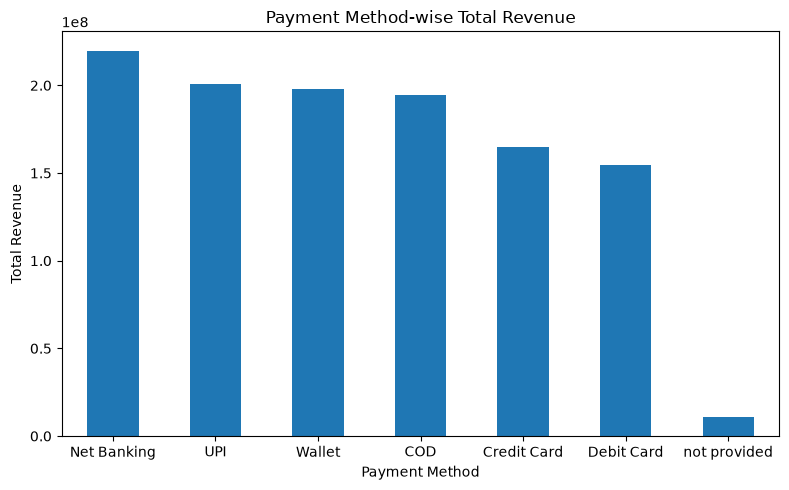

In [23]:
payment_revenue = (
    df.groupby("PaymentMethod")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
payment_revenue.plot(kind="bar")
plt.title("Payment Method-wise Total Revenue")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### City-wise Customer & Revenue Analysis

In [12]:
city_insight = (
    df.groupby("City")
      .agg(
          Orders=("OrderId", "nunique"),
          Customers=("CustomerId", "nunique"),
          Total_Revenue=("TotalAmount", "sum"),
          Avg_Order_Value=("TotalAmount", "mean"),
          Avg_Distance=("DeliveryDistanceKM", "mean")
      )
      .sort_values("Total_Revenue", ascending=False)
)

city_insight.head(10)

,Orders,Customers,Total_Revenue,Avg_Order_Value,Avg_Distance
City,,,,,
Pune,7457,7170,1.223233e+08,16532.403688,37.090206
Hyderabad,7445,7152,1.177672e+08,15961.937957,29.569522
Chennai,6984,6721,1.042110e+08,15031.160264,32.387928
Delhi,7478,7186,1.037079e+08,13995.668788,38.264911
Kolkata,7203,6930,9.787731e+07,13739.095142,30.575815
Jaipur,7210,6915,9.501280e+07,13286.645066,31.464217
Ahmedabad,7097,6826,8.982255e+07,12762.511199,44.493790
Patna,7128,6818,8.772232e+07,12425.257116,30.550354
Lucknow,7189,6906,8.167425e+07,11463.052291,31.059599


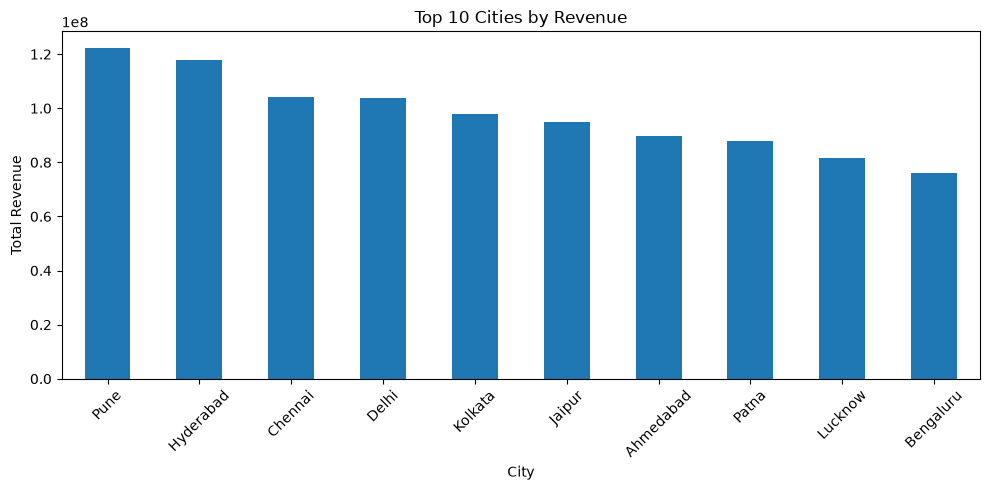

In [24]:
city_revenue = (
    df.groupby("City")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
city_revenue.plot(kind="bar")
plt.title("Top 10 Cities by Revenue")
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Marketing Channel ka Revenue Performance

In [13]:
marketing_insight = (
    df.groupby("MarketingChannel")
      .agg(
          Orders=("OrderId", "nunique"),
          Total_Revenue=("TotalAmount", "sum"),
          Total_Spend=("Spend90d", "sum"),
          Avg_Order_Value=("TotalAmount", "mean")
      )
)

marketing_insight["Revenue_per_Spend"] = (
    marketing_insight["Total_Revenue"] /
    marketing_insight["Total_Spend"]
)

marketing_insight.sort_values(
    "Revenue_per_Spend",
    ascending=False
)

,Orders,Total_Revenue,Total_Spend,Avg_Order_Value,Revenue_per_Spend
MarketingChannel,,,,,
Paid Search,15813,2.700592e+08,1.884714e+08,17244.057132,1.432892
not provided,1684,2.691923e+07,1.884188e+07,16138.627560,1.428692
Email,8443,1.432733e+08,1.058302e+08,17099.090140,1.353804
Direct,14772,2.045375e+08,1.854690e+08,13972.093720,1.102812
Social,12999,1.581220e+08,1.857846e+08,12277.506837,0.851104
Organic,25908,2.622406e+08,3.284987e+08,10196.377545,0.798300
Affiliate,8595,7.765629e+07,1.044241e+08,9106.037566,0.743662


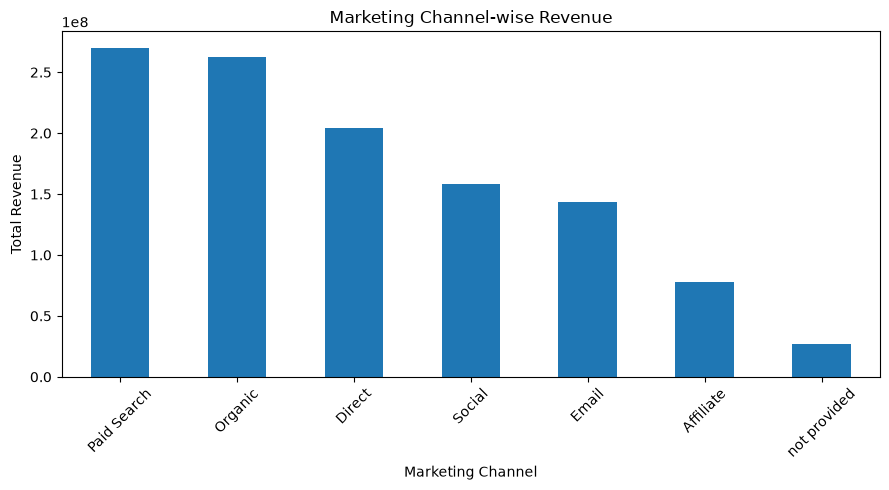

In [25]:
marketing_revenue = (
    df.groupby("MarketingChannel")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))
marketing_revenue.plot(kind="bar")
plt.title("Marketing Channel-wise Revenue")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Shipping Days vs Customer Rating

In [14]:
shipping_insight = (
    df.groupby("ShippingDays")
      .agg(
          Orders=("OrderId", "nunique"),
          Avg_Rating=("Rating", "mean"),
          Avg_Revenue=("TotalAmount", "mean")
      )
      .sort_index()
)

shipping_insight

,Orders,Avg_Rating,Avg_Revenue
ShippingDays,,,
0.0,161,3.957143,32596.676025
1.0,15666,4.027059,10018.815512
2.0,16950,4.029927,14669.859705
3.0,15312,4.036146,13233.889232
4.0,11962,4.022132,13871.059939
...,...,...,...
177.0,2,4.200000,1956.635000
178.0,1,3.900000,2072.080000
179.0,4,4.250000,14661.797500


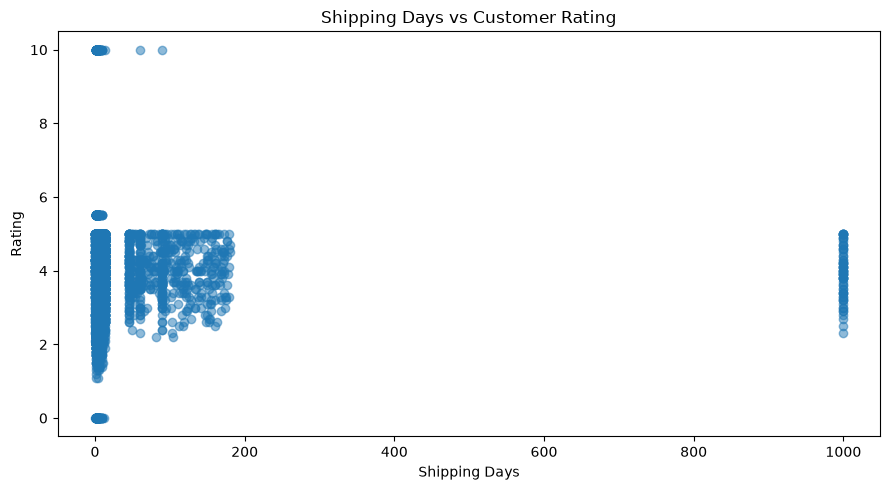

In [26]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df["ShippingDays"],
    df["Rating"],
    alpha=0.5
)

plt.title("Shipping Days vs Customer Rating")
plt.xlabel("Shipping Days")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

In [15]:
df[["ShippingDays", "Rating"]].corr()

,ShippingDays,Rating
ShippingDays,1.000000,-0.003112
Rating,-0.003112,1.000000


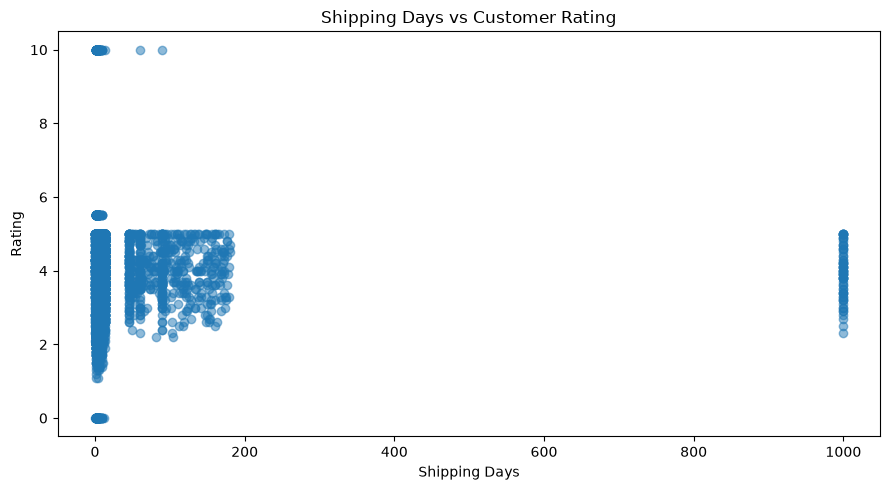

In [27]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df["ShippingDays"],
    df["Rating"],
    alpha=0.5
)

plt.title("Shipping Days vs Customer Rating")
plt.xlabel("Shipping Days")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

### Device-wise Shopping Behaviour

In [16]:
device_insight = (
    df.groupby("Device")
      .agg(
          Orders=("OrderId", "nunique"),
          Customers=("CustomerId", "nunique"),
          Total_Revenue=("TotalAmount", "sum"),
          Avg_Order_Value=("TotalAmount", "mean"),
          Avg_Quantity=("Quantity", "mean")
      )
      .sort_values("Total_Revenue", ascending=False)
)

device_insight

,Orders,Customers,Total_Revenue,Avg_Order_Value,Avg_Quantity
Device,,,,,
Mobile,62392,44939,7.698204e+08,12422.468499,2.921145
Desktop,20086,17963,2.876537e+08,14447.697256,3.194537
Tablet,4603,4481,7.645533e+07,16781.239985,2.533449
not provided,1048,1042,8.878744e+06,8561.951890,4.270992


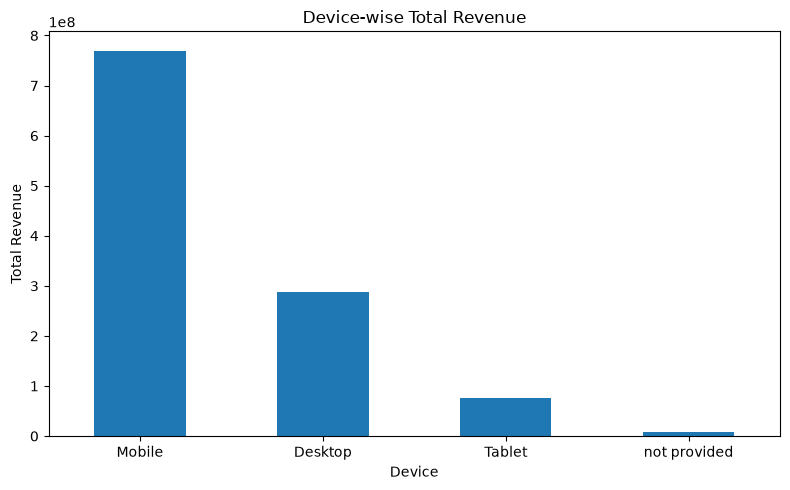

In [28]:
device_revenue = (
    df.groupby("Device")["TotalAmount"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
device_revenue.plot(kind="bar")
plt.title("Device-wise Total Revenue")
plt.xlabel("Device")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Order Status Analysis

In [17]:
status_insight = (
    df.groupby("OrderStatus")
      .agg(
          Orders=("OrderId", "nunique"),
          Total_Revenue=("TotalAmount", "sum"),
          Avg_Order_Value=("TotalAmount", "mean"),
          Avg_Rating=("Rating", "mean")
      )
      .sort_values("Orders", ascending=False)
)

status_insight

,Orders,Total_Revenue,Avg_Order_Value,Avg_Rating
OrderStatus,,,,
Delivered,62476,8.644506e+08,13941.402473,4.030868
Shipped,8489,8.310312e+07,9859.190476,4.022497
Processing,6040,6.775079e+07,11331.459043,4.027644
Cancelled,5618,4.890343e+07,8765.627136,4.025307
Returned,4836,7.050842e+07,14680.079908,4.025284
not provided,681,8.091729e+06,11952.332718,4.014244


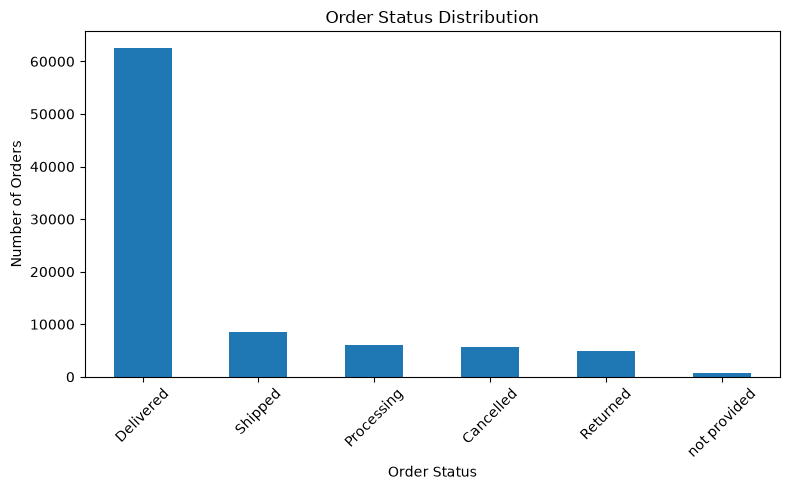

In [29]:
status_count = df["OrderStatus"].value_counts()

plt.figure(figsize=(8, 5))
status_count.plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
status_percentage = (
    df["OrderStatus"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status_percentage

OrderStatus
Delivered       70.92
Shipped          9.62
Processing       6.84
Cancelled        6.37
Returned         5.48
not provided     0.77
Name: proportion, dtype: float64

### Monthly Revenue Trend

In [19]:
df["OrderDate"] = pd.to_datetime(
    df["OrderDate"],
    errors="coerce"
)

monthly_insight = (
    df.dropna(subset=["OrderDate"])
      .groupby(df["OrderDate"].dt.to_period("M"))
      .agg(
          Orders=("OrderId", "nunique"),
          Customers=("CustomerId", "nunique"),
          Total_Revenue=("TotalAmount", "sum"),
          Avg_Order_Value=("TotalAmount", "mean"),
          Avg_Rating=("Rating", "mean")
      )
)

monthly_insight

,Orders,Customers,Total_Revenue,Avg_Order_Value,Avg_Rating
OrderDate,,,,,
2024-01,3707,3629,39549418.45,10770.538794,4.015808
2024-02,3445,3379,47722638.30,13962.152809,4.043077
2024-03,3651,3584,39861197.43,11032.714484,4.016292
2024-04,3559,3481,36040843.37,10198.314479,4.020568
2024-05,3673,3603,23251344.58,6384.224212,4.050286
2024-06,3562,3488,45345637.96,12820.366966,4.010780
2024-07,3673,3594,52917413.45,14537.750948,4.031364
2024-08,3684,3598,21589557.78,5905.240093,4.030402
2024-09,3553,3478,39343966.08,11161.408817,4.027912


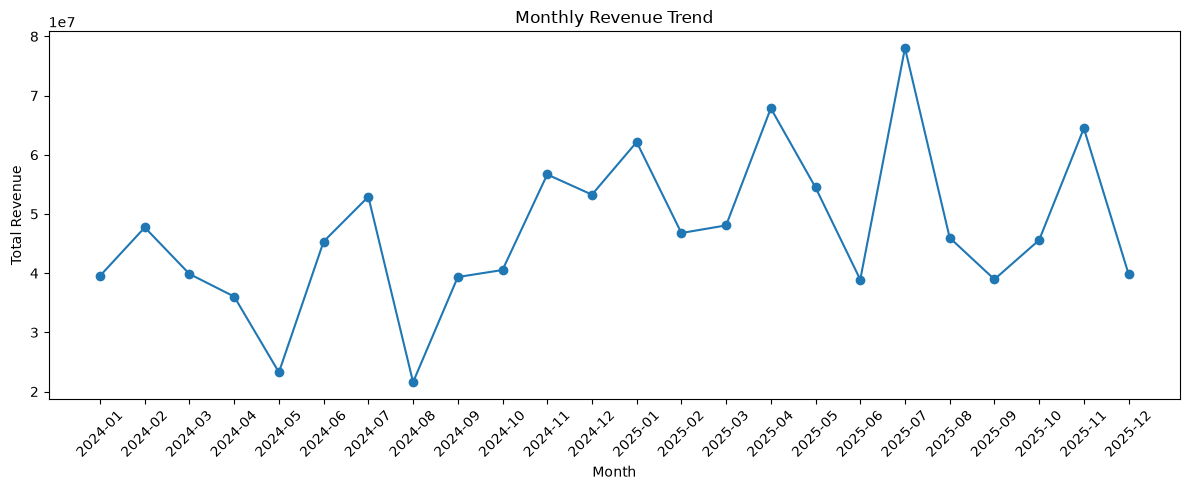

In [30]:
df["OrderDate"] = pd.to_datetime(
    df["OrderDate"],
    errors="coerce"
)

monthly_revenue = (
    df.dropna(subset=["OrderDate"])
      .groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"]
      .sum()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()